In [1]:
# Data Processing
import pandas as pd
import numpy as np

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import display
from IPython.display import Image
import graphviz
import matplotlib.pyplot as plt
import seaborn as sns

### Model Settings
**Stride Length**<br>
    -1  :   sentence fragment<br>
    0   :   all entries<br>
    1   :   stride_len = 1<br>
    2   :   stride_len = 2<br>
    3   :   stride_len = 3<br>
    4   :   stride_len = 4<br>

**Features**<br>
    "T" : Traditional<br>
    "L" : Lexical<br>
    "B" : Traditional + Lexical<br>

**Split**<br>
    1   :   Use one dataset for all stories<br>
    2   :   Split stories into training and testing dataset <br>

In [ ]:
stride_length = -1
features = "T"
split = 1

In [3]:
if stride_length == 0:
    print("No stride length filter applied.")
    model_name = f"All N-Grams"
elif stride_length == -1:
    print("Returning sentence fragments.")
    model_name = f"Sentence Fragments"
elif stride_length in [1, 2, 3, 100]:
    print(f"Filtering dataset with stride length: {stride_length}")
    model_name = f"N = {stride_length}"
else:
    print(f"Invalid stride length: {stride_length}")

Returning sentence fragments.


In [6]:
df= pd.read_csv("../../tables/dataset.csv")

df = df[df['text_num'] != 18]
df = df.drop(columns=['word_num'])

print(df.head())

   text_num  grade_level  stride_len  stride_index     n_gram  noun_tr  \
0        79            6           1             0         si      0.0   
1        79            6           1             1       Shah      1.0   
2        79            6           1             2      Jahan      1.0   
3        79            6           1             3         ay      0.0   
4        79            6           1             4  nagpatayo      0.0   

   verb_tr  type_tr  lex_density  lex_foreign  sent_len  word_len  syll_num  \
0      0.0      1.0          0.0          0.0    12.375       2.0       0.0   
1      0.0      1.0          1.0          0.0    12.375       4.0       1.0   
2      0.0      1.0          1.0          0.0    12.375       5.0       2.0   
3      0.0      1.0          0.0          0.0    12.375       2.0       0.0   
4      1.0      1.0          1.0          0.0    12.375       9.0       3.0   

   poly_num  
0         0  
1         0  
2         1  
3         0  
4         

In [7]:
#Filtering the dataset based on stride length
if stride_length == -1:
    df = df[(df['stride_len'] > 3) & (df['stride_len'] < 100)]
elif stride_length == 0:
    df = df
else:
    df = df[df['stride_len'] == stride_length]

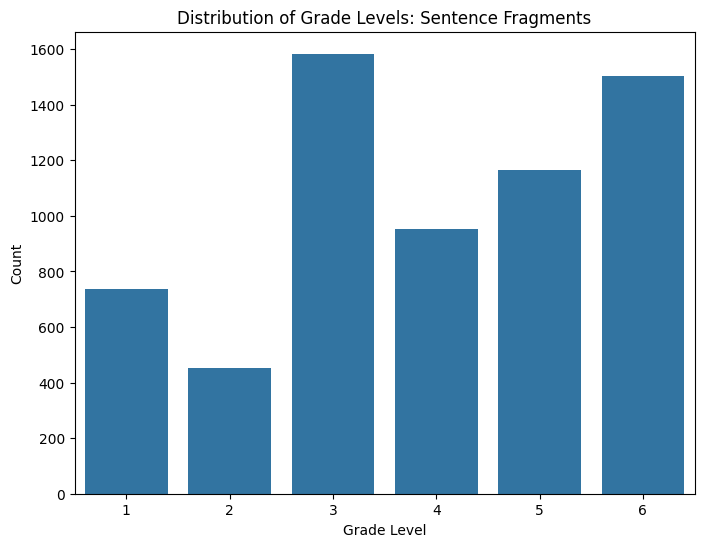

In [8]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df)
plt.title(f'Distribution of Grade Levels: {model_name}')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

In [9]:
# Undersampling to balance the dataset
min_count = df['grade_level'].value_counts().min()
    
# Group by grade level and sample min_count entries from each group
undersampled_df = df.groupby('grade_level').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
# df = df.groupby('grade_level').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_17259/3854243763.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = df.groupby('grade_level').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)


In [10]:
feature_set = ['grade_level', 'text_num', 'stride_len', 'stride_index', 'n_gram']

if features.capitalize() == "B":
    feature_set = feature_set
elif features.capitalize() == "T":
    feature_set += ['noun_tr', 'verb_tr', 'type_tr', 'lex_density', 'lex_foreign']
elif features.capitalize() == "L":
    feature_set += ['sent_len', 'word_len', 'syll_num', 'poly_num']
else:
    raise KeyError("Invalid feature set selected. Please choose 'B', 'T', or 'L'.")

In [11]:
X = df.drop(columns=feature_set)
y = df['grade_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
rf = RandomForestClassifier(n_estimators=100, warm_start=True, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42, warm_start=True)

In [13]:
y_pred = rf.predict(X_train)

accuracy = accuracy_score(y_train, y_pred)
print("Accuracy:", accuracy)

print(f"Classification Report:\n{classification_report(y_train, y_pred)}\n")

Accuracy: 0.9534974599452911
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       580
           2       1.00      1.00      1.00       387
           3       1.00      1.00      1.00      1251
           4       1.00      1.00      1.00       762
           5       0.87      0.87      0.87       922
           6       0.90      0.90      0.90      1216

    accuracy                           0.95      5118
   macro avg       0.96      0.96      0.96      5118
weighted avg       0.95      0.95      0.95      5118




In [14]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(f"Classification Report:\n{classification_report(y_test, y_pred)}\n")

Accuracy: 0.82421875
Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.93      0.96       157
           2       0.82      0.88      0.85        67
           3       0.93      0.91      0.92       333
           4       0.90      0.94      0.92       192
           5       0.64      0.63      0.64       244
           6       0.72      0.74      0.73       287

    accuracy                           0.82      1280
   macro avg       0.83      0.84      0.84      1280
weighted avg       0.83      0.82      0.82      1280




Text(0.5, 1.0, 'Visualizing Important Features: Sentence Fragments')

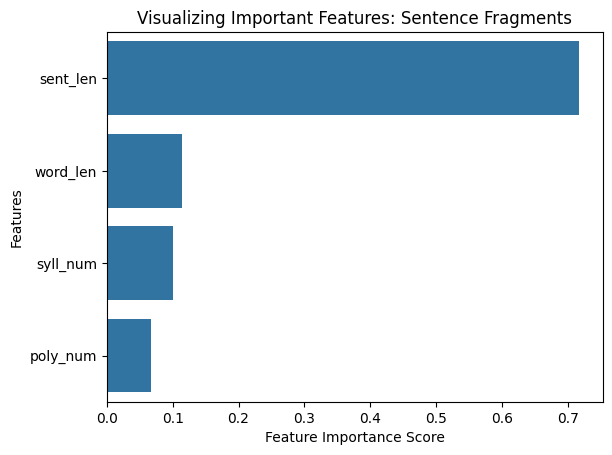

In [15]:
feature_scores = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title(f"Visualizing Important Features: {model_name}")

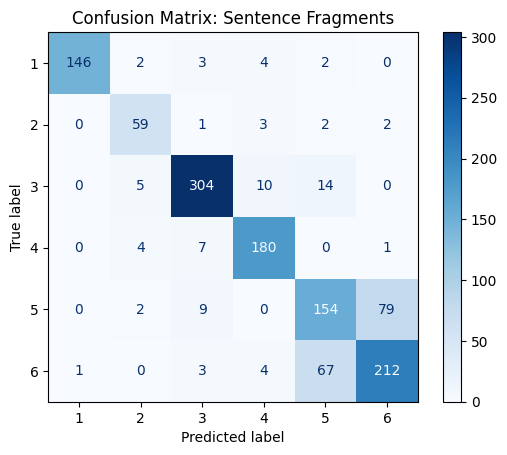

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap='Blues', values_format='d')  # Customize the colormap and format
plt.title(f"Confusion Matrix: {model_name}")
plt.show()

In [17]:
param_dist = {
'n_estimators': randint(50, 500),
'max_depth': randint(1, 50),
'min_samples_split': randint(2, 20),
'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier()
rand_search = RandomizedSearchCV(rf, 
                                param_distributions = param_dist, 
                                n_iter=5, 
                                cv=5)

rand_search.fit(X_train, y_train)
best_rf = rand_search.best_estimator_

print('Best hyperparameters:',  rand_search.best_params_)

/Users/gilbert/Library/Python/3.10/lib/python/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best hyperparameters: {'max_depth': 17, 'max_features': None, 'min_samples_split': 15, 'n_estimators': 249}


Accuracy: 0.88203125
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       157
           2       1.00      1.00      1.00        67
           3       0.99      0.98      0.98       333
           4       1.00      1.00      1.00       192
           5       0.69      0.69      0.69       244
           6       0.75      0.77      0.76       287

    accuracy                           0.88      1280
   macro avg       0.91      0.91      0.91      1280
weighted avg       0.88      0.88      0.88      1280




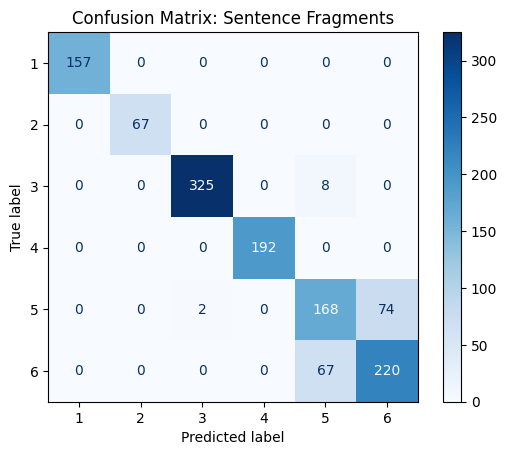

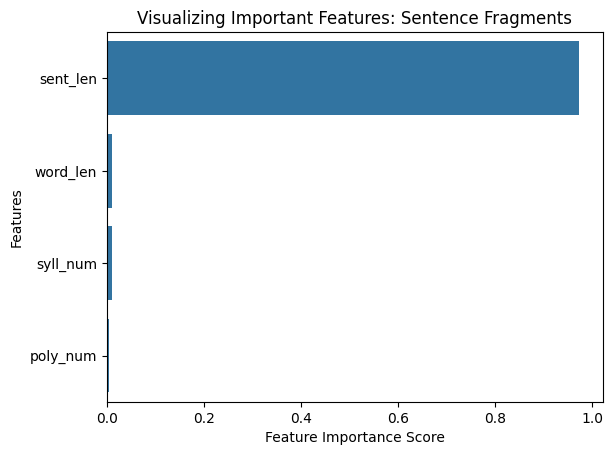

In [ ]:
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(f"Classification Report:\n{classification_report(y_test, y_pred)}\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues', values_format='d')  # Customize the colormap and format
plt.title(f"Confusion Matrix: {model_name}")
plt.show()

feature_scores = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title(f"Visualizing Important Features: {model_name}")
plt.show()